# Analyze GB Structures

In [1]:
path = "results/small_box/ml/dataset.csv"
subset = "gb10"  # one of: "full", "gb5", "gb10"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

try:
    import umap
except ImportError:
    raise ImportError("umap-learn is not installed. Install with: pip install umap-learn")

df = pd.read_csv(path)
print(f"Loaded {len(df)} samples, {len(df.columns)} columns")
print(f"Sigma values: {sorted(df['sigma'].unique())}")


Loaded 64 samples, 1382 columns
Sigma values: [np.int64(3), np.int64(5), np.int64(9), np.int64(11), np.int64(13), np.int64(17), np.int64(19), np.int64(25), np.int64(27), np.int64(29), np.int64(33), np.int64(37), np.int64(41), np.int64(43)]


In [3]:
# Classify each GB as twist, tilt, or other.
# Twist: rotation axis parallel to plane normal  → |axis × plane| / (|axis||plane|) ≈ 0
# Tilt:  rotation axis orthogonal to plane normal → |axis · plane| / (|axis||plane|) ≈ 0
# (Note: cross product = 0 for parallel vectors; dot product = 0 for orthogonal vectors)
ANGLE_TOL = 0.1  # sine/cosine threshold (~6°)

axes_vec = df[["axis_x", "axis_y", "axis_z"]].values
plane_vec = df[["plane_x", "plane_y", "plane_z"]].values

axis_norm = np.linalg.norm(axes_vec, axis=1, keepdims=True)
plane_norm = np.linalg.norm(plane_vec, axis=1, keepdims=True)
axes_hat = axes_vec / np.where(axis_norm == 0, 1, axis_norm)
plane_hat = plane_vec / np.where(plane_norm == 0, 1, plane_norm)

dot = np.einsum("ij,ij->i", axes_hat, plane_hat)          # cos θ
cross_mag = np.linalg.norm(np.cross(axes_hat, plane_hat), axis=1)  # sin θ

def classify(d, c):
    if c < ANGLE_TOL:   return "twist"   # parallel  → small cross product
    if abs(d) < ANGLE_TOL: return "tilt" # orthogonal → small dot product
    return "other"

df["gb_type"] = [classify(d, c) for d, c in zip(dot, cross_mag)]
print(df["gb_type"].value_counts().to_string())

# Categorical color mapping for gb_type
TYPE_COLORS = {"twist": "#1f77b4", "tilt": "#ff7f0e", "other": "#2ca02c"}


gb_type
tilt     48
twist    16


## TODO 1: Histograms of gb10 descriptors

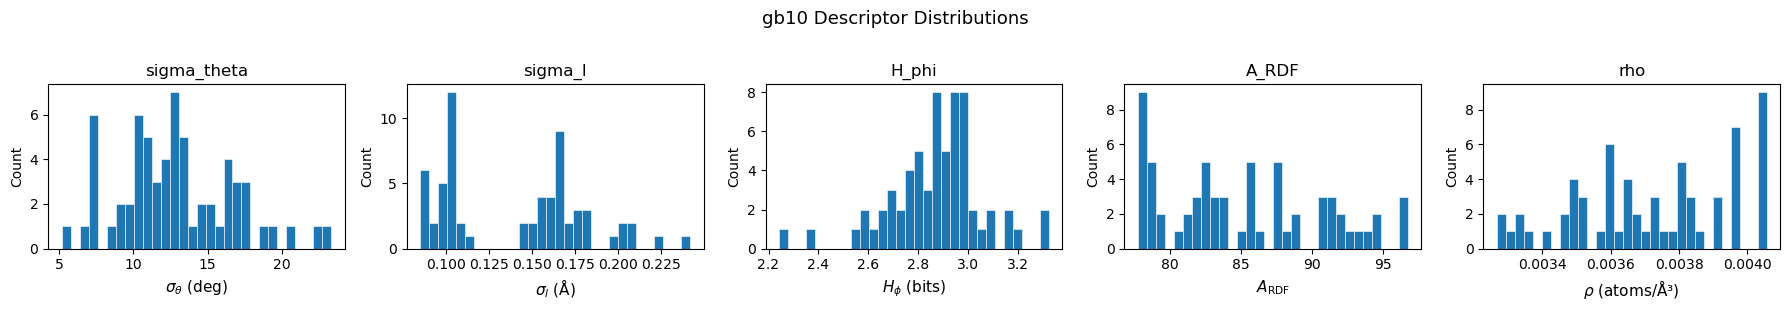

In [4]:
desc_cols = [f"{subset}_sigma_theta", f"{subset}_sigma_l", f"{subset}_H_phi",
             f"{subset}_A_RDF", f"{subset}_rho"]
desc_labels = {
    f"{subset}_sigma_theta": r"$\sigma_\theta$ (deg)",
    f"{subset}_sigma_l":     r"$\sigma_l$ (Å)",
    f"{subset}_H_phi":       r"$H_\phi$ (bits)",
    f"{subset}_A_RDF":       r"$A_\mathrm{RDF}$",
    f"{subset}_rho":         r"$\rho$ (atoms/Å³)",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, desc_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(desc_labels[col], fontsize=11)
    ax.set_ylabel("Count")
    ax.set_title(col.replace(f"{subset}_", ""))
plt.suptitle(f"{subset} Descriptor Distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Clustering on gb10 descriptors (PCA + UMAP), colored by sigma

PCA explained variance: [0.731 0.219]

Loading matrix:
               PC1    PC2
sigma_theta  0.469  0.389
sigma_l      0.481  0.239
H_phi        0.441  0.397
A_RDF        0.433 -0.531
rho         -0.408  0.593


/Users/dawsonren/miniconda3/envs/chem-calorine/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


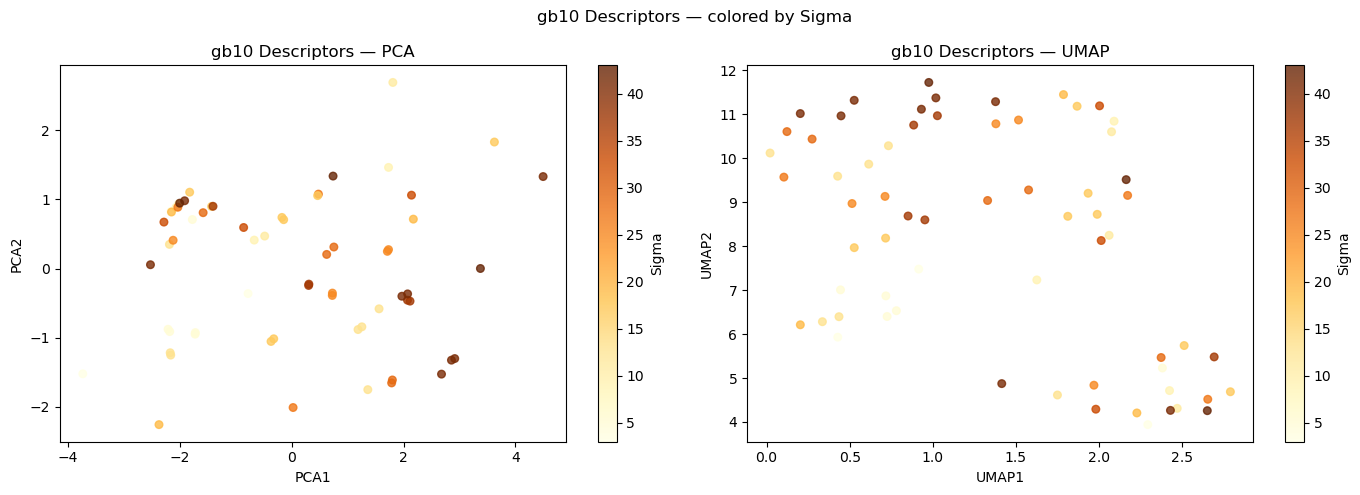

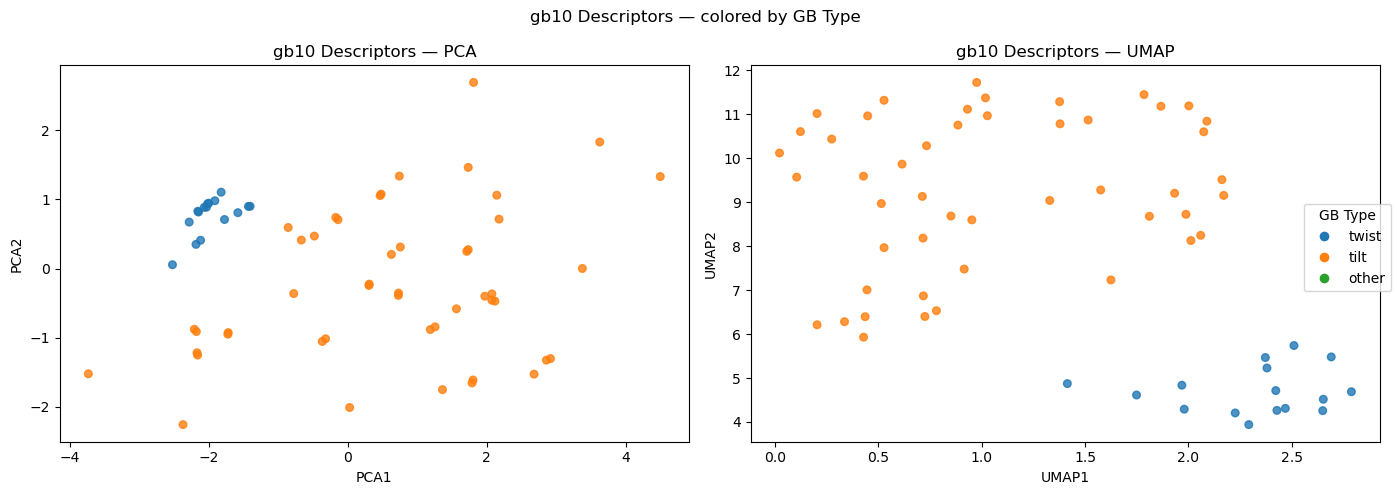

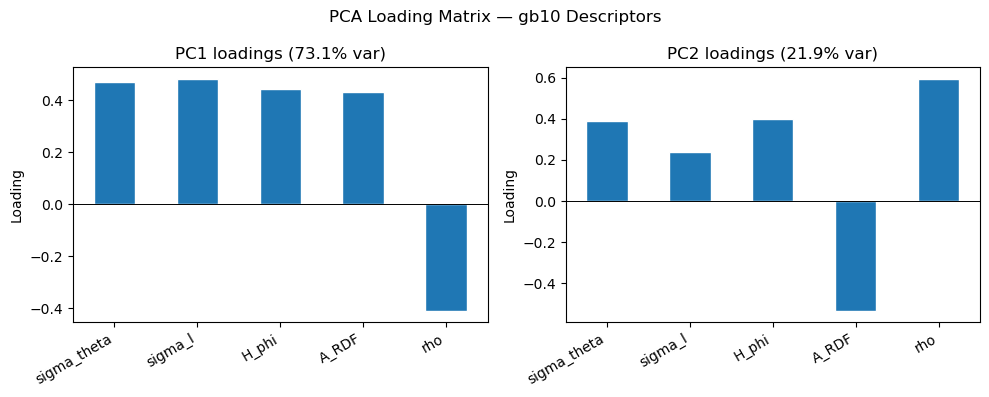

In [5]:
mask = df[desc_cols].notna().all(axis=1)
X_desc = df.loc[mask, desc_cols].values
sigma_vals = df.loc[mask, "sigma"].values
type_vals  = df.loc[mask, "gb_type"].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_desc)

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Loading matrix (which descriptors drive each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=[c.replace(f"{subset}_", "") for c in desc_cols],
    columns=["PC1", "PC2"],
)
print("PCA explained variance:", np.round(pca.explained_variance_ratio_, 3))
print("\nLoading matrix:")
print(loadings.round(3))

# --- UMAP ---
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

def scatter_pair(embeddings, labels, c, cmap=None, colorbar_label=None,
                 cat_colors=None, suptitle=""):
    """Plot PCA + UMAP side-by-side. Use cmap for continuous or cat_colors for categorical."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, coords, title in zip(axes, embeddings, labels):
        if cat_colors is not None:
            point_colors = [cat_colors[v] for v in c]
            ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=30, alpha=0.8)
        else:
            sc = ax.scatter(coords[:, 0], coords[:, 1], c=c, cmap=cmap, s=30, alpha=0.8)
            plt.colorbar(sc, ax=ax, label=colorbar_label)
        ax.set_title(f"{subset} Descriptors — {title}", fontsize=12)
        ax.set_xlabel(f"{title}1")
        ax.set_ylabel(f"{title}2")
    if cat_colors is not None:
        handles = [plt.Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=col, markersize=8, label=k)
                   for k, col in cat_colors.items()]
        fig.legend(handles=handles, title="GB Type", loc="center right", fontsize=10)
    plt.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    plt.show()

scatter_pair([X_pca, X_umap], ["PCA", "UMAP"],
             c=sigma_vals, cmap="YlOrBr", colorbar_label="Sigma",
             suptitle=f"{subset} Descriptors — colored by Sigma")

scatter_pair([X_pca, X_umap], ["PCA", "UMAP"],
             c=type_vals, cat_colors=TYPE_COLORS,
             suptitle=f"{subset} Descriptors — colored by GB Type")

# --- PCA loading bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    loadings[pc].plot(kind="bar", ax=ax, edgecolor="white")
    ax.set_title(f"{pc} loadings ({pca.explained_variance_ratio_[int(pc[-1])-1]:.1%} var)")
    ax.set_ylabel("Loading")
    ax.axhline(0, color="k", linewidth=0.7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.suptitle(f"PCA Loading Matrix — {subset} Descriptors", fontsize=12)
plt.tight_layout()
plt.show()


## Kernel PCA on averaged SOAP vectors (gb10), colored by sigma

SOAP similarity kernel: $K(A, B) = \left(\frac{\mathbf{p}_A \cdot \mathbf{p}_B}{\|\mathbf{p}_A\| \|\mathbf{p}_B\|}\right)^\zeta$

Run twice: $\zeta = 1$ (cosine similarity) and $\zeta = 2$ (common value).

Found 450 SOAP dimensions for gb10


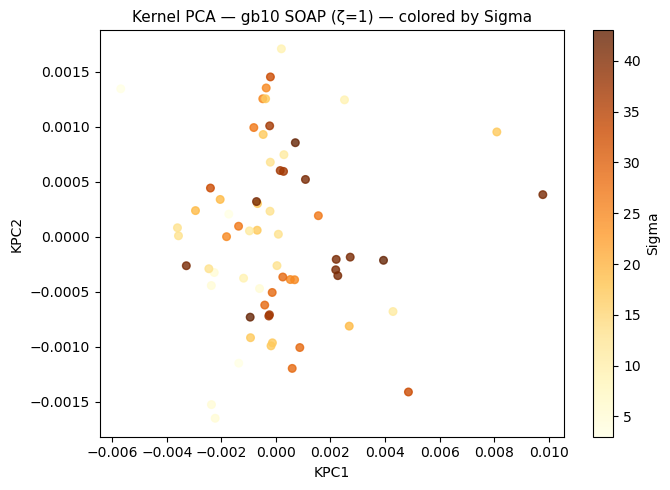

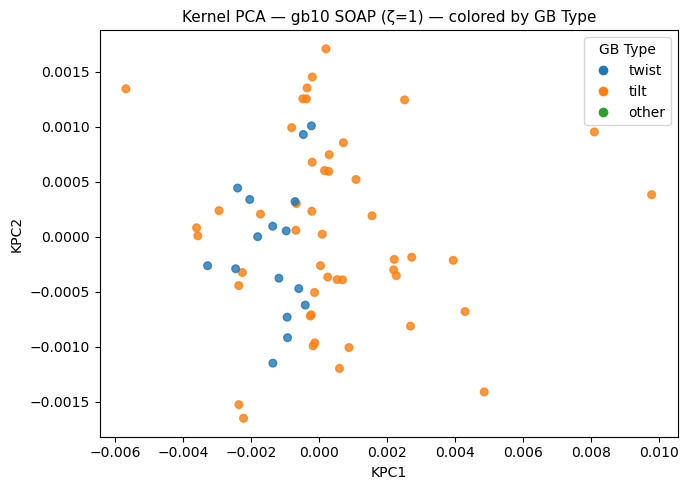

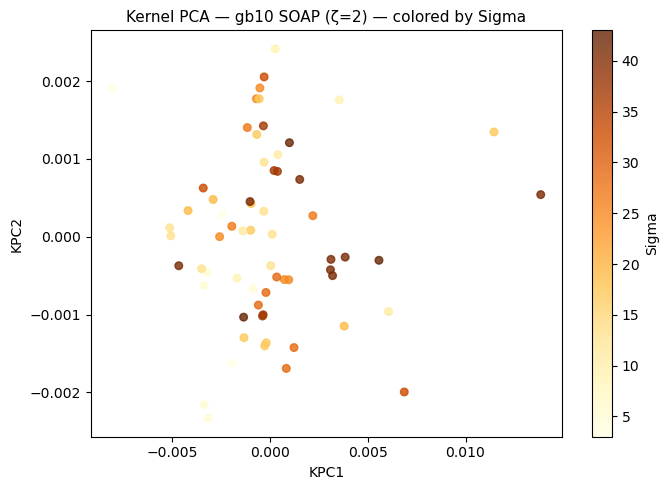

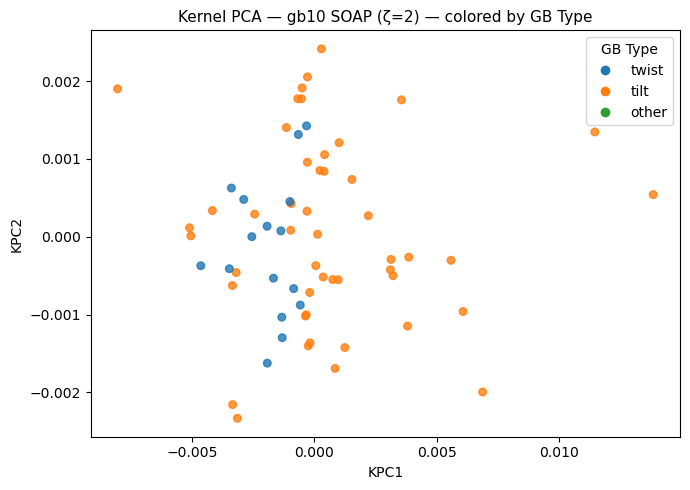

In [6]:
soap_cols = [c for c in df.columns if c.startswith(f"soap_{subset}_")]
print(f"Found {len(soap_cols)} SOAP dimensions for {subset}")

soap_mask = df[soap_cols].notna().all(axis=1)
X_soap = df.loc[soap_mask, soap_cols].values
sigma_soap = df.loc[soap_mask, "sigma"].values
type_soap  = df.loc[soap_mask, "gb_type"].values

# Row-normalize SOAP vectors (required for cosine kernel)
norms = np.linalg.norm(X_soap, axis=1, keepdims=True)
X_soap_norm = X_soap / np.where(norms == 0, 1, norms)

# Precompute cosine similarity matrix
K_cos = X_soap_norm @ X_soap_norm.T  # shape (n, n), values in [-1, 1]

def soap_kernel_pca(K, zeta):
    """Return 2D kernel PCA embedding for the given kernel and zeta."""
    kpca = KernelPCA(n_components=2, kernel="precomputed")
    return kpca.fit_transform(K ** zeta)

def plot_kpca(X_kpca, c, zeta, cmap=None, colorbar_label=None, cat_colors=None, color_title=""):
    fig, ax = plt.subplots(figsize=(7, 5))
    if cat_colors is not None:
        point_colors = [cat_colors[v] for v in c]
        ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=point_colors, s=30, alpha=0.8)
        handles = [plt.Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=col, markersize=8, label=k)
                   for k, col in cat_colors.items()]
        ax.legend(handles=handles, title="GB Type", fontsize=10)
    else:
        sc = ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=c, cmap=cmap, s=30, alpha=0.8)
        plt.colorbar(sc, ax=ax, label=colorbar_label)
    ax.set_title(f"Kernel PCA — {subset} SOAP (ζ={zeta}) — {color_title}", fontsize=11)
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")
    plt.tight_layout()
    plt.show()

for zeta in [1, 2]:
    X_kpca = soap_kernel_pca(K_cos, zeta)
    plot_kpca(X_kpca, sigma_soap, zeta, cmap="YlOrBr", colorbar_label="Sigma",
              color_title="colored by Sigma")
    plot_kpca(X_kpca, type_soap, zeta, cat_colors=TYPE_COLORS,
              color_title="colored by GB Type")
